# DiffTRe: Top-Down Training of Coarse-Grained Water MLP

In [1]:
%env CUDA_VISIBLE_DEVICES=0
%env MPI4JAX_SKIP_ABI_CHECK=1
%config InlineBackend.figure_formats = ["svg"]

from pathlib import Path
import sys

import jax

jax.config.update("jax_default_matmul_precision", "highest")

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as onp
import optax
from matplotlib.ticker import MaxNLocator

from chemtrain import quantity, trainers, ensemble
from chemtrain.compose import mace_jax as mace_jax_compose
from chemtrain.data import preprocessing
from jax_md import partition, simulate, space
from jax_md_mod import custom_energy, custom_quantity

tutorial_dir = Path("examples/01_difftre").resolve()
if tutorial_dir.is_dir():
    sys.path.insert(0, str(tutorial_dir))
from data_loading import load_coarse_grained_water


plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})

COLORS = {"target": "black", "initial": "0.55", "fit": "tab:blue", "adf": "tab:orange"}

def style_axes(axes):
    for ax in onp.atleast_1d(axes).flat:
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(alpha=0.25)


def save_figure(fig, path):
    fig.savefig(path.with_suffix(".svg"), bbox_inches="tight")


env: CUDA_VISIBLE_DEVICES=0
env: MPI4JAX_SKIP_ABI_CHECK=1


/ds/project/paul/projects/chemAiML26/venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
<frozen importlib._bootstrap>:488: RuntimeWarning: nanobind: type 'DeviceProp' was already registered!

<frozen importlib._bootstrap>:488: RuntimeWarning: nanobind: type 'GPUTimer' was already registered!



## Data Loading

In [2]:
reference_data = load_coarse_grained_water()

# Reference data to construct an initial simulation state
box = reference_data.box
dataset = reference_data.dataset
position_dataset = reference_data.positions
force_dataset = reference_data.forces

# Experimental reference data
#
# RDF: Average particle-distance in comparison to ideal gas
# ADF: Average triplet angle for particles within a cutoff sphere
r_rdf, rdf = reference_data.rdf_distances, reference_data.rdf
alpha_adf, adf = reference_data.adf_angles, reference_data.adf

## Model Setup

In [3]:
displacement_fn, shift_fn = space.periodic_general(box, fractional_coordinates=True)

r_cutoff = 0.6

# We use the reference data to estimate the required size of the neighbor list.
nbrs_init, (_, _, avg_num_neighbors, *_) = preprocessing.allocate_neighborlist(
    dataset, displacement_fn, box, r_cutoff,
    capacity_multiplier=1.5, batch_size=10,
    format=partition.Dense)

# In this tutorial, we use a strictly local MACE model provided by mace-jax.
# It can model many-body interactions, necessary to learn the ADF.
mace_config = {
    "num_interactions": 1, # makes it strictly local
    "correlation": 2, # correlate two neighbors
    "hidden_irreps": "16x0e + 16x1o",
    "MLP_irreps": "16x0e",
    "max_ell": 2,
    "num_bessel": 8,
    "num_polynomial_cutoff": 6,
}

# Initialize model parameters. Only the shape of
# the initial sample data matters here.
r_init = dataset["R"][0]
nbrs_init = nbrs_init.update(r_init)
species_init = jnp.zeros(r_init.shape[0], dtype=int)

key = jax.random.PRNGKey(0)
mace_variables, apply_fn, mace_model_config = mace_jax_compose.mace_jax_neighborlist(
    displacement=displacement_fn,
    r_cutoff=r_cutoff,
    n_species=1,
    avg_num_neighbors=avg_num_neighbors,
    max_edge_multiplier=1.5,
    per_particle=False,
    mace_config=mace_config,
)

init_params = mace_variables["params"]

The dataset has max. 39 neighbors per particle and max. 28438 edges in total.
Always recompute the neighbor list!


In [4]:
# The randomly initialized MACE model differs substantially from the target potential.
# In particular, the strong repulsive interactions are absent.
# Therefore, we supplement the MACE model with a simple prior potential.

prior_energy_fn = custom_energy.truncated_lennard_jones_neighborlist(
    displacement_fn, box, epsilon=1.0, sigma=0.31,
    initialize_neighbor_list=False
)

# In this example, we simply add the independently computed energies.
# More advanced connections are possible, e.g., for electrostatic
# interactions.
def energy_fn_template(params):

    def energy_fn(position, neighbor, **kwargs):
        # We only have one species (water molecule), so we can
        # fix the model input here.
        species = jnp.zeros((position.shape[0],), dtype=int)

        pot = prior_energy_fn(position, neighbor)
        pot += apply_fn(params, position, neighbor, species=species)

        return pot

    return energy_fn

## Structural Targets

In [5]:
# First, we sanitize the experimental reference data by interpolating
# it onto a regular grid. For the ADF, we determine the first solvation
# shell extent from the reference RDF. Only triplets within that
# shell are considered.

rdf_discretization = custom_quantity.rdf_discretization(0.9, nbins=300)
adf_disc = custom_quantity.adf_discretization(nbins=150)

rdf_params = custom_quantity.RDFParams(
    jnp.interp(rdf_discretization[0], r_rdf, rdf), *rdf_discretization
)

# Determine the outer cutoff from the solvation shell
valid = (
    (rdf_params.rdf_bin_centers > 0.28)
    & (rdf_params.rdf_bin_centers < 0.4)
)
adf_outer_idx = onp.argmin(rdf_params.reference[valid])
adf_outer = rdf_params.rdf_bin_centers[valid][adf_outer_idx]
print(f"Solvation-shell minimum at {adf_outer}.")

adf_params = custom_quantity.ADFParams(
    jnp.interp(adf_disc[0], alpha_adf, adf), *adf_disc, adf_outer, 0.0
)

## Microscopic observables ###################################################

# Here, we specify how to compute the instantaneous RDFs and ADFs
# for a single microstate. These functions correspond to the a_k quantities
# from the lecture. We bundle them in a dictionary.

rdf_fn = custom_quantity.init_rdf(displacement_fn, rdf_params)
adf_fn = custom_quantity.init_adf_nbrs(displacement_fn, adf_params, r_init=r_init, nbrs_init=nbrs_init)

quantities = {
    "rdf": rdf_fn,
    "adf": adf_fn
}

## Ensemble averages #########################################################

# The experimental observations are ensemble averages of the instantaneous
# ADFs and RDFs. Here, we initialize the computation of these ensemble
# averages. The returned functions accepts pre-computed microscopic observables
# as dictionary with corresponding weights for DiffTRe.

rdf_observable = quantity.observables.init_traj_mean_fn("rdf")
adf_observable = quantity.observables.init_traj_mean_fn("adf")

Solvation-shell minimum at 0.343500018119812.
[ADF] Estimates 1540260 max. triplets in neighbor list and 37888 max. triplets in cutoff-shell.


## Reference Simulation

In [6]:
## Simulation settings #######################################################

# For a coarse-grained model with only heavy atoms, we can
# select larger time steps than in typical atomistic systems.
dt = 0.01
gamma = 100.
kT = quantity.kb * 300.0
masses = jnp.ones((position_dataset.shape[1],)) * 18.02

# The simulation protocol for our initial model evaluation
# and for training is the same. We sample 35 ps in total,
# but only keep 30 ps for evaluation. Moreover, we
# only retain every tenth sample, corresponding to 0.1 ps.
timings = ensemble.sampling.process_printouts(
    time_step=dt, total_time=35.0, print_every=0.1,
    t_equilib=5.0
)

## Initialize simulation state ###############################################

# We select an initial configuration randomly from the
# reference trajectory. The specific choice should not
# matter because we are equilibrating beforehand.
key, split = jax.random.split(key)
selection = jax.random.choice(
    split, jnp.arange(position_dataset.shape[0]), shape=(1,), replace=False)
r_init = position_dataset[selection, ...].squeeze(0)
nbrs_init = nbrs_init.update(r_init)

# Similar to the energy_fn_template, we need to adjust
# the simulation if our parameters change. The template
# returns a new simulator function.
init_ref_state, sim_template = ensemble.sampling.initialize_simulator_template(
    simulate.nvt_langevin, shift_fn=shift_fn, nbrs=nbrs_init,
    init_with_PRNGKey=True, extra_simulator_kwargs={"kT": kT, "gamma": gamma, "dt": dt}
)

# We initialize a simulation reference state, which we
# will use to start the training and which also determines
# the shapes required for JAX JIT compilation.
key, split = jax.random.split(key)
reference_state = init_ref_state(
    split, r_init,
    energy_or_force_fn=energy_fn_template(init_params),
    init_sim_kwargs={"mass": masses, "neighbor": nbrs_init}
)

Always recompute the neighbor list!
Always recompute the neighbor list!
Limit the maximum number of edges to 42288 (5286 / 125 edges per particle).


/ds/project/paul/projects/chemAiML26/venv/lib/python3.13/site-packages/jax/_src/numpy/reductions.py:235: UserWarning: Explicitly requested dtype float64 requested in sum is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return _reduction(a, "sum", lax.add, 0, preproc=_cast_to_numeric,
/ds/project/paul/projects/chemAiML26/venv/lib/python3.13/site-packages/jax/_src/numpy/reductions.py:165: UserWarning: Explicitly requested dtype float64 requested in convert_element_type is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax.convert_element_type(result, dtype or result_dtype)


In [7]:
# The trajectory generator uses the simulator object and our
# simulation protocol (equilibration, sampling, etc.) to build
# a function that performs the complete simulation for us.
# It also computes the instantaneous quantities.
trajectory_generator = ensemble.sampling.trajectory_generator_init(
    sim_template, energy_fn_template, timings, quantities)

## Initial simulation ########################################################

# We use the generator directly to compute the RDF and ADF for the
# initial untrained model.
trajectory = trajectory_generator(init_params, reference_state, box=box)

print(f"Average kT: {trajectory.aux['kT'].mean()}")

Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Average kT: 2.4655063152313232


## Initial Structure

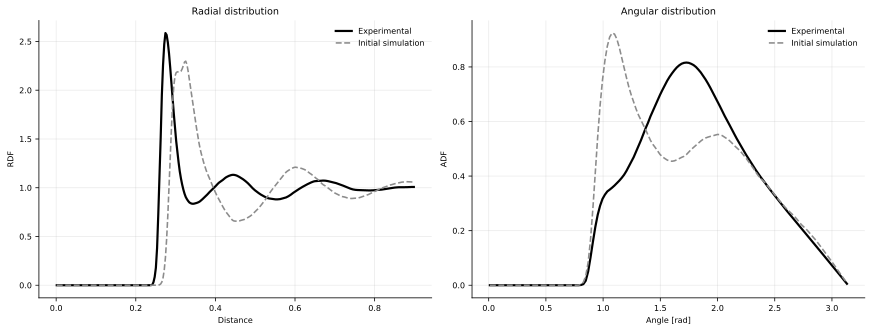

In [8]:
plot_dir = Path("plots")
plot_dir.mkdir(exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
style_axes(axes)

axes[0].plot(rdf_params.rdf_bin_centers, rdf_params.reference, color=COLORS["target"], lw=2.2, label="Experimental")
axes[0].plot(rdf_params.rdf_bin_centers, rdf_observable(trajectory.aux), color=COLORS["initial"], ls="--", lw=1.6, label="Initial simulation")
axes[0].set(xlabel="Distance", ylabel="RDF", title="Radial distribution")
axes[0].legend(frameon=False)

axes[1].plot(adf_params.adf_bin_centers, adf_params.reference, color=COLORS["target"], lw=2.2, label="Experimental")
axes[1].plot(adf_params.adf_bin_centers, adf_observable(trajectory.aux), color=COLORS["initial"], ls="--", lw=1.6, label="Initial simulation")
axes[1].set(xlabel="Angle [rad]", ylabel="ADF", title="Angular distribution")
axes[1].legend(frameon=False)
save_figure(fig, plot_dir / "initial_structure")

## DiffTRe Optimization

In [9]:
## Optimizer setup ###########################################################

# For the DiffTRe optimization, we first specify the optimization
# protocol. We use a first-order Adam optimizer with a learning-rate
# schedule.

num_iter = 150
initial_learning_rate = 2.0e-3
learning_rate_schedule = optax.cosine_decay_schedule(
    initial_learning_rate, decay_steps=num_iter, alpha=0.02
)
optimizer = optax.adam(learning_rate=learning_rate_schedule, b1=0.75, b2=0.95)

## DiffTRe setup #############################################################

# We initialize the DiffTRe trainer and set the
# recomputation threshold. A higher threshold can
# require more effort because more trajectory recomputations
# are necessary. However, too low a threshold might
# cause noise.
difftre_trainer = trainers.Difftre(
    init_params,
    optimizer,
    reweight_ratio=0.75
    
)

# A state point specifies the exact thermodynamic
# conditions, e.g., pressure, temperature, box size, etc.
# Moreover, we can specify different targets to train on.
# In our simple example, we only have one state point.
difftre_trainer.add_statepoint(
    energy_fn_template=energy_fn_template,
    simulator_template=sim_template,
    timings=timings,
    state_kwargs={"box": box, "kT": kT},
    quantities=quantities,
    observables={
        "rdf": rdf_observable,
        "adf": adf_observable
    },
    targets={
        "rdf": {
            "target": rdf_params.reference,
            "gamma": 1.0
        },
        "adf": {
            "target": adf_params.reference,
            "gamma": 1.0
        }
    },
    neighbor_fn=nbrs_init,
    reference_state=reference_state
)

/ds/project/paul/projects/chemAiML26/external/chemtrain/chemtrain/ensemble/reweighting.py:842: UserWarning: Propagation function is not safe by default. Do not forget to use the wrapper around the compute function to ensure that the neighborlist does not overflow.
  warnings.warn(


Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
[Propagation] Time for trajectory compilation 0: 0.15752933025360108 mins
[Propagation] Time for trajectory simulation 0: 0.0766352375348409 mins


In [10]:
# Run the optimization.
difftre_trainer.train(num_iter)

Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
[Propagate] Effective sample size: 300.0000305175781 (225.0) -> Recompute is False
[Statepoint 0]
	kT = 2.464 ref_kT = 2.494
	Predicted entropy: -0.00024176182341761887 
	Predicted free_energy: -2.3788006728864275e-06 

[DiffTRe] Epoch 0
	Epoch loss = 0.25155
	Gradient norm: 0.032196786254644394
	Elapsed time = 0.403 min
[Propagate] Effective sample size: 11.929524421691895 (225.0) -> Recompute is True
[Statepoint 0]
	kT = 2.463 ref_kT = 2.494
	Predicted entropy: 0.457266628742218 
	Predicted free_energy: -197.05784606933594 

[DiffTRe] Epoch 1
	Epoch loss = 0.23559
	Gradient norm: 0.02269328385591507
	Elapsed time = 0.106 min
[Propagate] Effective sample size: 3.0007

## Initial vs Trained Predictions

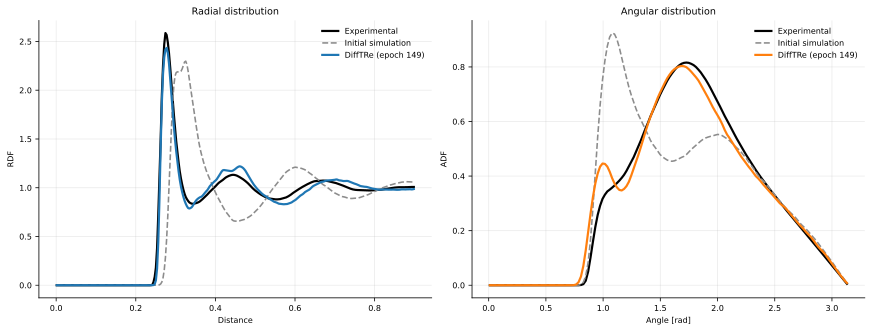

In [11]:
completed_epochs = onp.array(sorted(difftre_trainer.predictions[0]))
last_epoch = int(completed_epochs[-1])
last_prediction = difftre_trainer.predictions[0][last_epoch]

plot_dir = Path("plots")
plot_dir.mkdir(exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
style_axes(axes)

axes[0].plot(rdf_params.rdf_bin_centers, rdf_params.reference, color=COLORS["target"], lw=2.2, label="Experimental")
axes[0].plot(rdf_params.rdf_bin_centers, rdf_observable(trajectory.aux), color=COLORS["initial"], ls="--", lw=1.6, label="Initial simulation")
axes[0].plot(rdf_params.rdf_bin_centers, last_prediction["rdf"], color=COLORS["fit"], lw=2.2, label=f"DiffTRe (epoch {last_epoch})")
axes[0].set(xlabel="Distance", ylabel="RDF", title="Radial distribution")
axes[0].legend(frameon=False)

axes[1].plot(adf_params.adf_bin_centers, adf_params.reference, color=COLORS["target"], lw=2.2, label="Experimental")
axes[1].plot(adf_params.adf_bin_centers, adf_observable(trajectory.aux), color=COLORS["initial"], ls="--", lw=1.6, label="Initial simulation")
axes[1].plot(adf_params.adf_bin_centers, last_prediction["adf"], color=COLORS["adf"], lw=2.2, label=f"DiffTRe (epoch {last_epoch})")
axes[1].set(xlabel="Angle [rad]", ylabel="ADF", title="Angular distribution")
axes[1].legend(frameon=False)
save_figure(fig, plot_dir / "difftre_structural_fit")

## Convergence

Final weighted loss: 5.0601e-03
Plots saved in /ds/project/paul/projects/chemAiML26/examples/01_difftre/plots


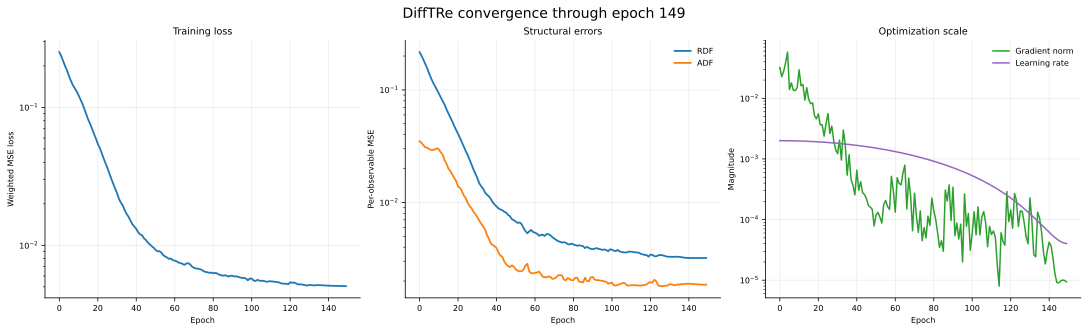

In [12]:
losses = onp.asarray(difftre_trainer.epoch_losses, dtype=float)
gradient_norms = onp.asarray(difftre_trainer.gradient_norm_history, dtype=float)
epochs = onp.arange(losses.size)

rdf_mse = onp.array([
    onp.mean((difftre_trainer.predictions[0][epoch]["rdf"] - rdf_params.reference) ** 2)
    for epoch in completed_epochs
])
adf_mse = onp.array([
    onp.mean((difftre_trainer.predictions[0][epoch]["adf"] - adf_params.reference) ** 2)
    for epoch in completed_epochs
])
nominal_learning_rates = onp.asarray([learning_rate_schedule(epoch) for epoch in epochs])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), layout="constrained")
style_axes(axes)
for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

axes[0].semilogy(epochs, losses, color=COLORS["fit"], lw=1.8)
axes[0].set(xlabel="Epoch", ylabel="Weighted MSE loss", title="Training loss")

axes[1].semilogy(completed_epochs, rdf_mse, color=COLORS["fit"], lw=1.8, label="RDF")
axes[1].semilogy(completed_epochs, adf_mse, color=COLORS["adf"], lw=1.8, label="ADF")
axes[1].set(xlabel="Epoch", ylabel="Per-observable MSE", title="Structural errors")
axes[1].legend(frameon=False)

axes[2].semilogy(epochs, gradient_norms, color="tab:green", lw=1.5, label="Gradient norm")
axes[2].semilogy(epochs, nominal_learning_rates, color="tab:purple", lw=1.5, label="Learning rate")
axes[2].set(xlabel="Epoch", ylabel="Magnitude", title="Optimization scale")
axes[2].legend(frameon=False)

fig.suptitle(f"DiffTRe convergence through epoch {last_epoch}", fontsize=14)
save_figure(fig, plot_dir / "difftre_convergence")
print(f"Final weighted loss: {losses[-1]:.4e}")
print(f"Plots saved in {plot_dir.resolve()}")